# Lab 1
Create a free  Kaggle account if you havent already. 
Download the dataset https://www.kaggle.com/c/dogs-vs-cats/data
Place the images in folders: one for training cats, one for training dogs, and a smaller set for validation/testing

In [1]:
import tensorflow as tf
import os
import shutil
import random
from PIL import Image
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt


2025-08-28 16:36:52.084306: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Part 1: Data Preparation
Organize the dataset into separate folders for training (80%), validation (10%), and test (10%).
Resize all images to the same size (for example, 150x150 or 224x224 pixels).
Apply data augmentation (like random flips or rotations) to make your model more robust.

In [2]:
random.seed(42)

base_dir = './data/PetImages'
output_dir = './data'
classes = {'cat': 1000, 'dog': 1000}
splits = {'train': 0.8, 'val': 0.1, 'test': 0.1}

for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

for cls, n_images in classes.items():
    src_dir = os.path.join(base_dir, cls.capitalize())
    images = [f for f in os.listdir(src_dir) if f.lower().endswith('.jpg')]
    random.shuffle(images)
    images = images[:n_images]
    n_train = int(splits['train'] * n_images)
    n_val = int(splits['val'] * n_images)
    n_test = n_images - n_train - n_val

    split_files = {
        'train': images[:n_train],
        'val': images[n_train:n_train+n_val],
        'test': images[n_train+n_val:]
    }

    for split, files in split_files.items():
        for f in files:
            src = os.path.join(src_dir, f)
            dst = os.path.join(output_dir, split, cls, f)
            try:
                with Image.open(src) as img:
                    img = img.convert('RGB')
                    img = img.resize((150, 150))
                    img.save(dst)
            except Exception as e:
                print(f"Skipping {src}: {e}")
            
print("Selected and split 1000 cat and 1000 dog images into train/val/test folders.")

Selected and split 1000 cat and 1000 dog images into train/val/test folders.


## Part 2: Building the CNN
Start by creating a simple CNN with a few convolution + pooling layers.
Add fully connected layers at the end for classification.
Use an activation function like ReLU in hidden layers and sigmoid/softmax in the output layer.

In [3]:

IMG_SIZE = (150, 150)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base

# Add your own classification head
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=IMG_SIZE + (3,)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/var/folders/n1/vds_7_gd3d1g9hj0w_5t2r4c0000gn/T/ipykernel_9619/2493203503.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(
/opt/anaconda3/envs/tensorflow/lib/python3.11/site-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:

def remove_invalid_images(folder):
    num_removed = 0
    for root, _, files in os.walk(folder):
        for fname in files:
            if fname.lower().endswith('.jpg'):
                fpath = os.path.join(root, fname)
                try:
                    img = Image.open(fpath)
                    img.verify()
                    img = Image.open(fpath)
                    if img.mode not in ('RGB', 'L'):
                        print(f"Removing non-RGB/non-grayscale image: {fpath} (mode: {img.mode})")
                        os.remove(fpath)
                        num_removed += 1
                except Exception:
                    print(f"Removing corrupted image: {fpath}")
                    os.remove(fpath)
                    num_removed += 1
    print(f"Removed {num_removed} invalid or corrupted images.")

remove_invalid_images('./data/split')

Removed 0 invalid or corrupted images.


## Part 3: Training the Model
Compile the model with binary cross-entropy loss and an optimizer (like Adam).
Train the model for several epochs (start small, maybe 5–10).
Record the training and validation accuracy and loss after each epoch.

In [5]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
train_ds = tf.keras.utils.image_dataset_from_directory(
    './data/train',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    './data/val',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary'
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Found 1600 files belonging to 2 classes.
Found 200 files belonging to 2 classes.
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 424ms/step - accuracy: 0.8821 - loss: 0.2764 - val_accuracy: 0.9400 - val_loss: 0.1964
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step - accuracy: 0.9698 - loss: 0.0818 - val_accuracy: 0.9050 - val_loss: 0.2799
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 0.9638 - loss: 0.0903 - val_accuracy: 0.9350 - val_loss: 0.2094
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step - accuracy: 0.9860 - loss: 0.0348 - val_accuracy: 0.9400 - val_loss: 0.1848
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 392ms/step - accuracy: 0.9954 - loss: 0.0202 - val_accuracy: 0.9350 - val_loss: 0.2032
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 389ms/step - accuracy: 0.9978 - loss: 0.0115 - val_accuracy: 0.9350 - val_loss: 0.2103
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 397ms/step - accuracy: 1.0000 - loss: 0.0065 - val_accuracy: 0.9300 - val_loss: 0.2177
Epoch 8/10
50/50

## Part 4: Evaluation
Test the model on your unseen test set.
Report metrics: accuracy, precision, recall, and F1-score.
Create a confusion matrix to see where the model makes mistakes.

In [6]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    './data/test',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)

images = []
labels = []
for batch_images, batch_labels in test_ds:
    images.append(batch_images.numpy())
    labels.append(batch_labels.numpy())
images = np.concatenate(images)
labels = np.concatenate(labels)

test_ds = tf.keras.utils.image_dataset_from_directory(
    './data/test',
    image_size=(150, 150),
    batch_size=32,
    label_mode='binary',
    shuffle=False
)
y_pred_probs = model.predict(test_ds)
y_pred = (y_pred_probs.flatten() > 0.5).astype(int)

acc = accuracy_score(labels, y_pred)
prec = precision_score(labels, y_pred)
rec = recall_score(labels, y_pred)
f1 = f1_score(labels, y_pred)
cm = confusion_matrix(labels, y_pred)

print(f"Test Accuracy:  {acc:.3f}")
print(f"Precision:      {prec:.3f}")
print(f"Recall:         {rec:.3f}")
print(f"F1-score:       {f1:.3f}")
print("Confusion Matrix:")
print(cm)


Found 200 files belonging to 2 classes.
Found 200 files belonging to 2 classes.


2025-08-28 16:40:36.358810: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 507ms/step
Test Accuracy:  0.945
Precision:      0.968
Recall:         0.920
F1-score:       0.944
Confusion Matrix:
[[97  3]
 [ 8 92]]


## Part 5: Visualization
Pick a few test images and show the model’s predictions alongside the true labels.
Highlight at least 5 examples where the model was wrong and analyze why.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
/var/folders/n1/vds_7_gd3d1g9hj0w_5t2r4c0000gn/T/ipykernel_9619/2625285355.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"True: {int(labels[idx])}\nPred: {int(y_pred[idx])}")
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255]

Number of misclassified images: 20000


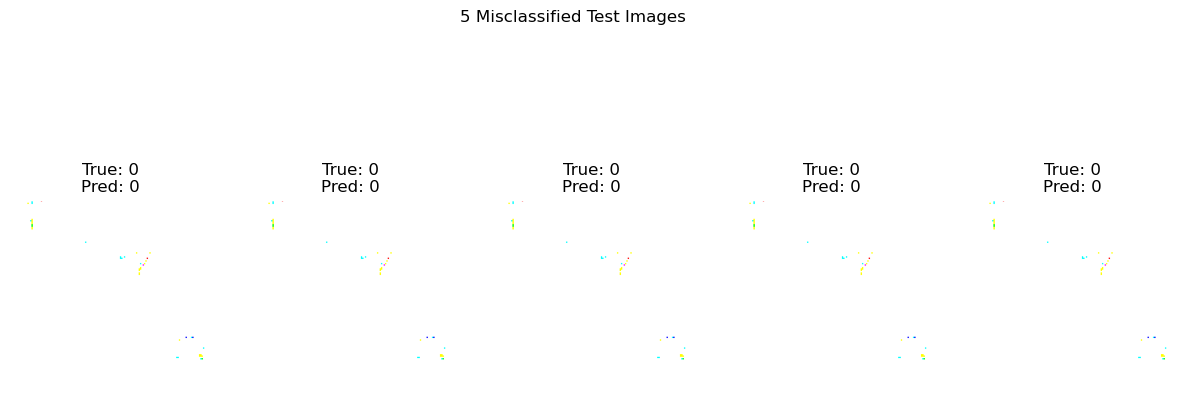

In [7]:
wrong_idx = np.where(y_pred != labels)[0]
print(f"Number of misclassified images: {len(wrong_idx)}")

if len(wrong_idx) > 0:
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(wrong_idx[:5]):
        plt.subplot(1, 5, i+1)
        img = images[idx]
        if img.max() <= 1.0:
            img = (img * 255).astype("uint8")
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True: {int(labels[idx])}\nPred: {int(y_pred[idx])}")
    plt.suptitle("5 Misclassified Test Images")
    plt.show()
else:
    print("No misclassified images in the test set.")

## Stretch Goals
Use transfer learning with a pre-trained network (like MobileNet or ResNet).
Compare the accuracy of your CNN vs. transfer learning.
Experiment with changing batch size, learning rate, or number of layers.